Importing dependencies

In [ ]:
from diffusers import DiffusionPipeline
import torch
import numpy as np
from PIL import Image

Load a pretrained diffusion model to cuda device using the DiffusionPipeline class from Hugging Face's diffusers library.

In [ ]:
pipeline = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5")
pipeline.to("cuda") # Use GPU, much faster than CPU, change runtime type if in Colab

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

Testing image generation

  0%|          | 0/50 [00:00<?, ?it/s]

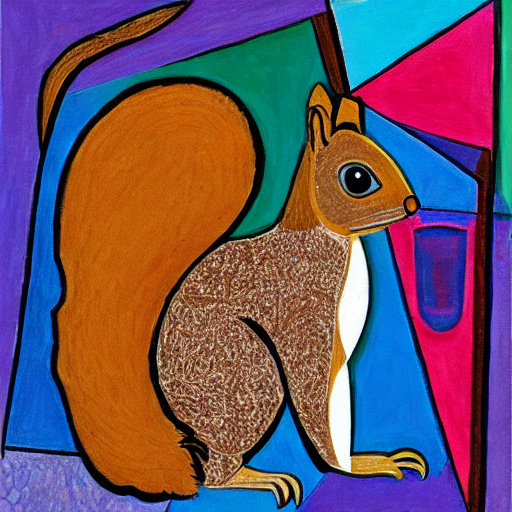

In [ ]:
pipeline("An image of a squirrel in Picasso style").images[0]

Script to create image of random noise to be used as the initial image for the diffusion model. Then generating an image using our random noise image.

In [ ]:
# Create a random noise array (values 0–255)
np.random.seed(42) # Using seed number to create same random pattern each time
noise = np.random.randint(0, 256, (512, 512, 3), dtype=np.uint8)

# Convert to image
img = Image.fromarray(noise)
img.save("random_noise.png")
img.show()

  0%|          | 0/50 [00:00<?, ?it/s]

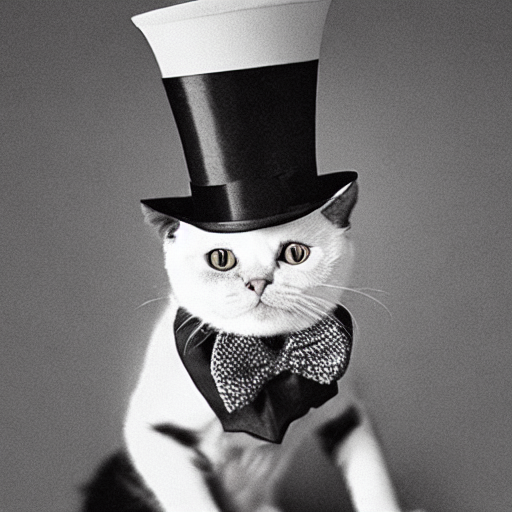

In [ ]:
pipeline("An image of a cat wearing a top hat", image=img).images[0]

Now We have implemented a partial image diffusion system. We start from random noise, remove a random square patch, and instruct a pretrained diffusion model to reconstruct only the missing block using a text prompt. This demonstrates how modern generative models perform conditional generation and inpainting. The missing region is recreated through iterative denoising guided by a probability distribution, which aligns with the idea that generative AI is fundamentally a prediction problem  predicting missing pixels step by step.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


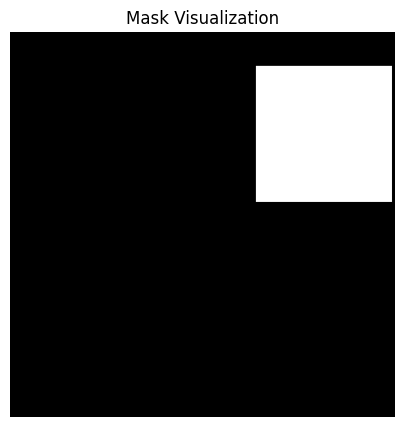

  0%|          | 0/52 [00:00<?, ?it/s]

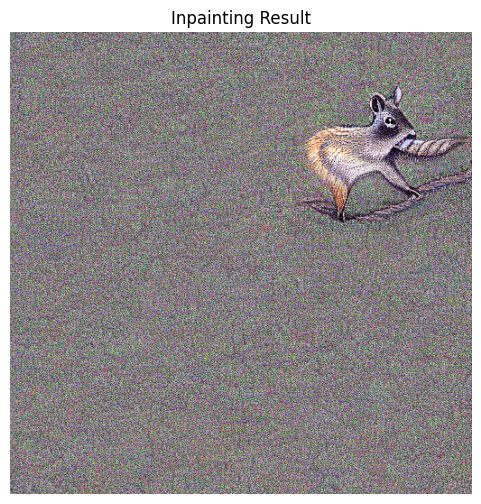

In [3]:
from diffusers import StableDiffusionInpaintPipeline
import torch
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random


# Load Inpainting Model
pipeline = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

# Disable NSFW Checker (prevent black outputs)
def dummy_checker(images, **kwargs):
    return images, [False] * len(images)

pipeline.safety_checker = dummy_checker

# Create Noise Image
noise = np.random.rand(512, 512, 3) * 255
noise = noise.astype(np.uint8)
noise_img_pil = Image.fromarray(noise)

# Create Mask (white = fill region)
mask = Image.new("L", (512, 512), 0)
draw = ImageDraw.Draw(mask)

block_size = 180  # adjust size here
x = random.randint(0, 512 - block_size)
y = random.randint(0, 512 - block_size)

draw.rectangle((x, y, x + block_size, y + block_size), fill=255)

# Show Mask
plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.title("Mask Visualization")
plt.axis("off")
plt.show()

# Reproducible Seed
generator = torch.Generator(device="cuda").manual_seed(42)

# Run Stable Diffusion Inpainting
result = pipeline(
    prompt="A detailed painting of a squirrel, Picasso cubism, bright palette, high detail",
    negative_prompt="deformed, blurry, abstract, messy, low quality",
    image=noise_img_pil,
    mask_image=mask,
    guidance_scale=12,
    strength=0.65,
    num_inference_steps=80,
    generator=generator
).images[0]

# Show Result
plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Inpainting Result")
plt.axis("off")
plt.show()
